# Data Preparation

This Notebook is meant to prepare the dataset into training an testing sets, while choosing interesting rows and features for the activity (especially feature selection and modelling activities)

In [24]:
import pandas as pd
from tree_helpers import plot_gini_all_features, RANDOM_STATE
import pprint
from constants import LABELLED_BY_STUDENTS_DINOS

In [25]:
df = pd.read_csv("../../public/raw_dino_tables/DinoDatasetFrench.csv", index_col="nom")
df

,régime_alimentaire,période,habitat,type,bipède,longueur (m),poids (kg),nommé_par,espèce,sous-ordre_taxonomique,famille_taxonomique
nom,,,,,,,,,,,
Tyrannosaurus,carnivore,Crétacé supérieur,États-Unis,grand théropode,True,12.00,7000,Osborn (1905),rex,Saurischia,Tyrannosaurinae
Allosaurus,carnivore,Jurassique supérieur,États-Unis,grand théropode,True,12.00,2000,Marsh (1877),fragilis,Saurischia,Allosauridae
Velociraptor,carnivore,Crétacé supérieur,Mongolie,petit théropode,True,1.80,7,Osborn (1924),mongoliensis,Saurischia,Dromaeosauridae
Spinosaurus,carnivore,Crétacé supérieur,Maroc,grand théropode,True,18.00,7400,Stromer (1915),aegyptiacus,Saurischia,Spinosaurinae
Carnotaurus,carnivore,Crétacé supérieur,Argentine,grand théropode,True,7.60,1600,Bonaparte (1985),sastrei,Saurischia,Abelisauridae
Giganotosaurus,carnivore,Crétacé inférieur,Argentine,grand théropode,True,12.50,8000,Coria and Salgado (1995),carolinii,Saurischia,Carcharodontosauridae
Ceratosaurus,carnivore,Jurassique supérieur,États-Unis,grand théropode,True,6.00,970,Marsh (1884),nasicornis,Saurischia,Neoceratosauria
Megalosaurus,carnivore,Jurassique moyen,Royaume-Uni,grand théropode,True,9.00,700,Ritgen (1826),bucklandii,Saurischia,Megalosaurinae
Compsognathus,carnivore,Jurassique supérieur,Allemagne,petit théropode,True,0.65,3,Wagner (1859),longipes,Saurischia,Compsognathidae


## Inspecting the Gini for each possible split

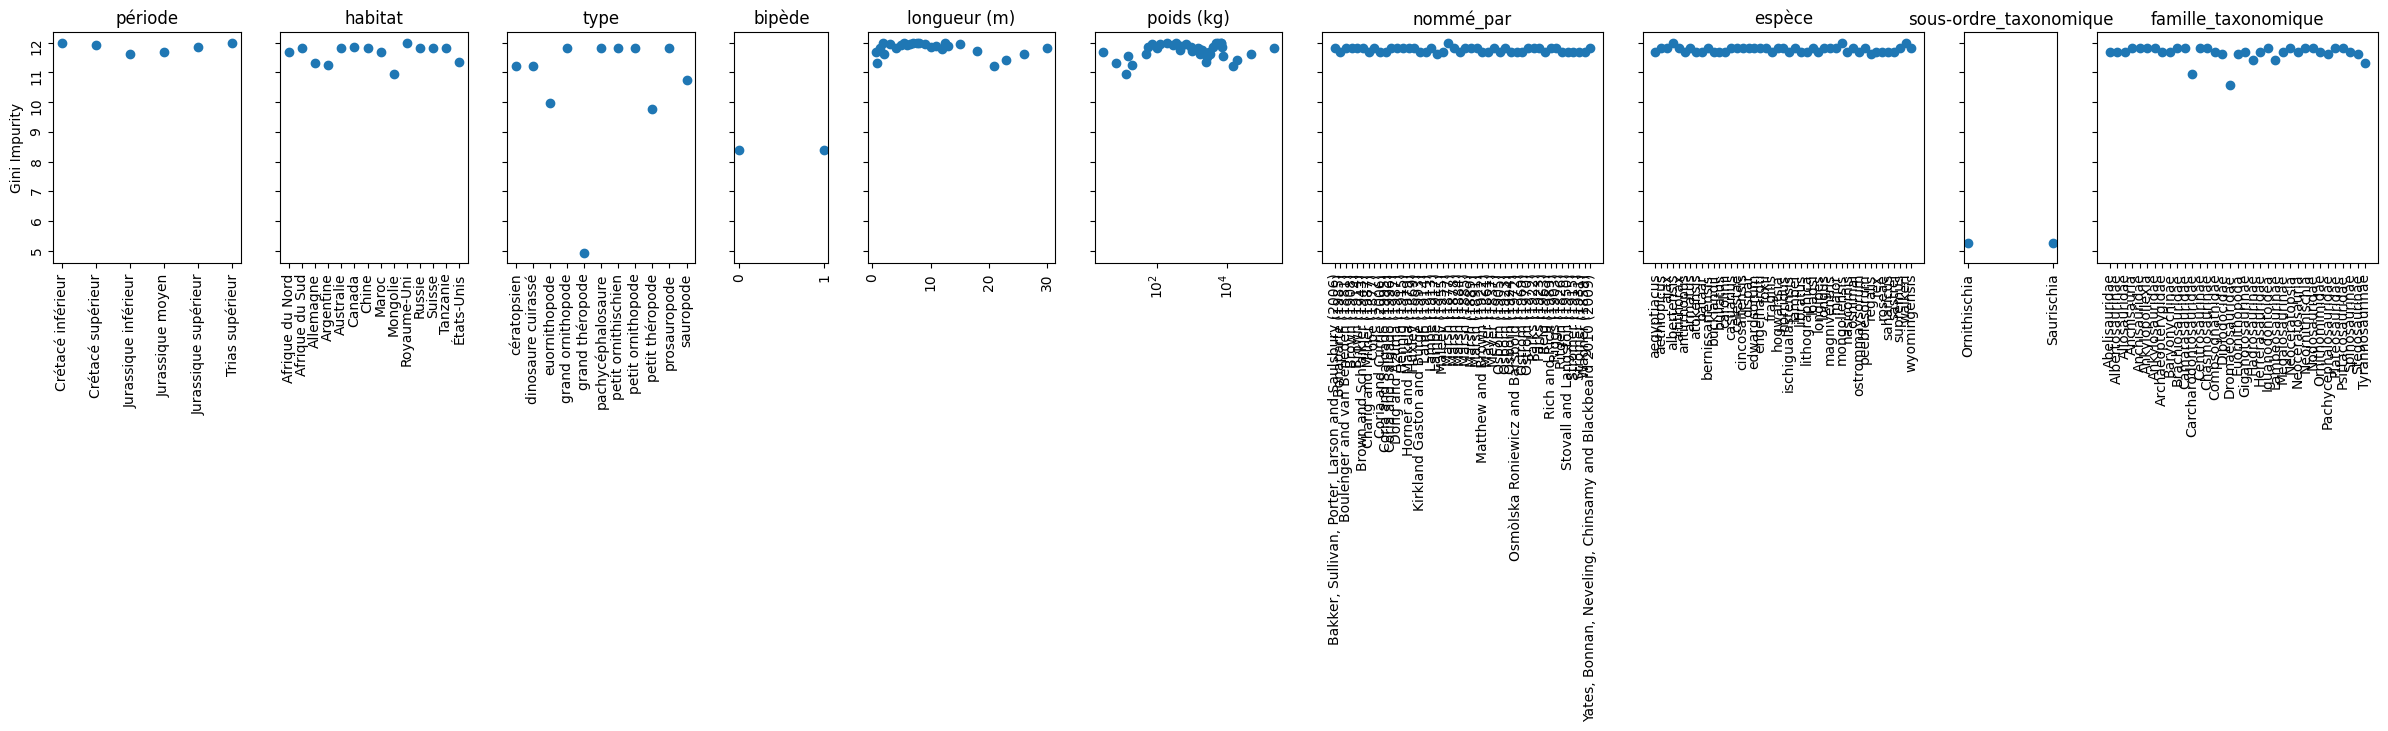

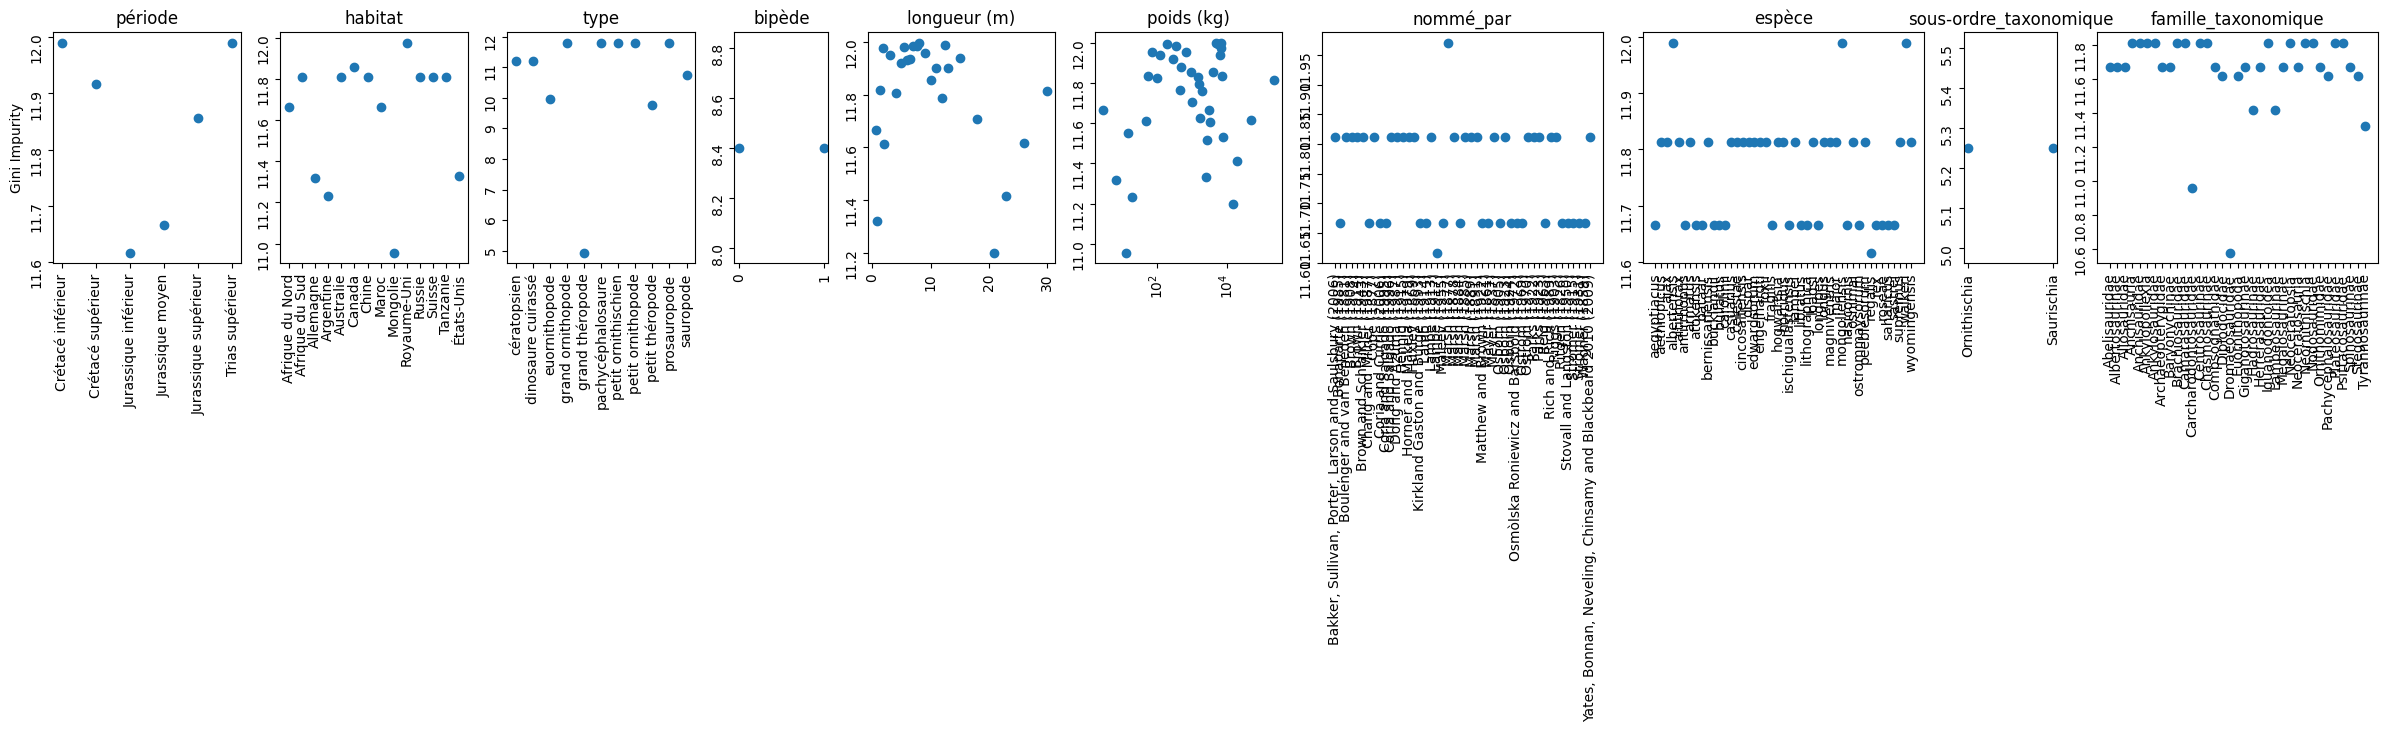

{'bipède': {np.False_: 8.4},
 'espèce': {'regalis': 11.617021276595745},
 'famille_taxonomique': {'Dromaeosauridae': 10.577777777777778},
 'habitat': {'Mongolie': 10.956521739130435},
 'longueur (m)': {np.float64(21.0): 11.2},
 'nommé_par': {'Lambe (1917)': 11.617021276595745},
 'poids (kg)': {np.int64(13): 10.956521739130435},
 'période': {'Jurassique inférieur': 11.617021276595745},
 'sous-ordre_taxonomique': {'Ornithischia': 5.25},
 'type': {'grand théropode': 4.9411764705882355}}
{'bipède': {np.False_: 8.4},
 'espèce': {'albertensis': 11.98936170212766},
 'famille_taxonomique': {'Anchisauria': 11.8125},
 'habitat': {'Royaume-Uni': 11.977777777777778},
 'longueur (m)': {np.float64(0.5): inf},
 'nommé_par': {'Marsh (1877)': 11.971014492753623},
 'poids (kg)': {np.int64(1): inf},
 'période': {'Crétacé inférieur': 11.990430622009569},
 'sous-ordre_taxonomique': {'Ornithischia': 5.25},
 'type': {'grand ornithopode': 11.8125}}


In [26]:
all_ginis, best_ginis, worst_ginis = plot_gini_all_features(df)
plot_gini_all_features(df, sharey=False)

pprint.pprint(best_ginis)
pprint.pprint(worst_ginis)

In [27]:
pprint.pprint(all_ginis)

{'bipède': {np.False_: 8.4, np.True_: 8.4},
 'espèce': {'aegyptiacus': 11.666666666666666,
            'aethiopicus': 11.8125,
            'ajax': 11.8125,
            'albertensis': 11.98936170212766,
            'altithorax': 11.8125,
            'antirrhopus': 11.666666666666666,
            'armatus': 11.8125,
            'atokensis': 11.666666666666666,
            'bataar': 11.666666666666666,
            'bernissartensis': 11.8125,
            'bucklandii': 11.666666666666666,
            'bullatus': 11.666666666666666,
            'carolinii': 11.666666666666666,
            'casuarius': 11.8125,
            'celestae': 11.8125,
            'cincosaltensis': 11.8125,
            'dispar': 11.8125,
            'edwardsorum': 11.8125,
            'engelhardti': 11.8125,
            'foxii': 11.8125,
            'fragilis': 11.666666666666666,
            'hogwartsia': 11.8125,
            'horridus': 11.8125,
            'ischigualastensis': 11.666666666666666,
            'lambe

## Splitting df into train and test

In [28]:
df

,régime_alimentaire,période,habitat,type,bipède,longueur (m),poids (kg),nommé_par,espèce,sous-ordre_taxonomique,famille_taxonomique
nom,,,,,,,,,,,
Tyrannosaurus,carnivore,Crétacé supérieur,États-Unis,grand théropode,True,12.00,7000,Osborn (1905),rex,Saurischia,Tyrannosaurinae
Allosaurus,carnivore,Jurassique supérieur,États-Unis,grand théropode,True,12.00,2000,Marsh (1877),fragilis,Saurischia,Allosauridae
Velociraptor,carnivore,Crétacé supérieur,Mongolie,petit théropode,True,1.80,7,Osborn (1924),mongoliensis,Saurischia,Dromaeosauridae
Spinosaurus,carnivore,Crétacé supérieur,Maroc,grand théropode,True,18.00,7400,Stromer (1915),aegyptiacus,Saurischia,Spinosaurinae
Carnotaurus,carnivore,Crétacé supérieur,Argentine,grand théropode,True,7.60,1600,Bonaparte (1985),sastrei,Saurischia,Abelisauridae
Giganotosaurus,carnivore,Crétacé inférieur,Argentine,grand théropode,True,12.50,8000,Coria and Salgado (1995),carolinii,Saurischia,Carcharodontosauridae
Ceratosaurus,carnivore,Jurassique supérieur,États-Unis,grand théropode,True,6.00,970,Marsh (1884),nasicornis,Saurischia,Neoceratosauria
Megalosaurus,carnivore,Jurassique moyen,Royaume-Uni,grand théropode,True,9.00,700,Ritgen (1826),bucklandii,Saurischia,Megalosaurinae
Compsognathus,carnivore,Jurassique supérieur,Allemagne,petit théropode,True,0.65,3,Wagner (1859),longipes,Saurischia,Compsognathidae


In [29]:
sub_df = df[~df.index.isin(LABELLED_BY_STUDENTS_DINOS.keys())]

df_carni = sub_df[sub_df["régime_alimentaire"] == "carnivore"]
df_herbi = sub_df[sub_df["régime_alimentaire"] == "herbivore"]

print(f"In total we have {df_carni.shape[0]} carnivores and {df_herbi.shape[0]} herbivores.")

# For training data: we take 15 dino in each diet
df_train = pd.concat([df[df.index.isin(LABELLED_BY_STUDENTS_DINOS.keys())],                   # 10 dino that were labelled by students
                      df_carni.sample(10, random_state=RANDOM_STATE),           # + 10 carnivores
                      df_herbi.sample(10, random_state=RANDOM_STATE)], axis=0)  # + 10 herbivores

# For test data: we take 5 from each dino in the remaining dino
base_df = sub_df.loc[list(set(sub_df.index) - set(df_train.index))]

df_herbi_test = base_df[base_df["régime_alimentaire"] == "herbivore"].sample(5, random_state=RANDOM_STATE)
df_carni_test = base_df[base_df["régime_alimentaire"] == "carnivore"].sample(5, random_state=RANDOM_STATE)

df_test = pd.concat([df_herbi_test, df_carni_test])

df_test

In total we have 16 carnivores and 23 herbivores.


,régime_alimentaire,période,habitat,type,bipède,longueur (m),poids (kg),nommé_par,espèce,sous-ordre_taxonomique,famille_taxonomique
nom,,,,,,,,,,,
Triceratops,herbivore,Crétacé supérieur,États-Unis,cératopsien,False,9.00,5500,Marsh (1889),horridus,Ornithischia,Chasmosaurinae
Lambeosaurus,herbivore,Crétacé supérieur,Canada,euornithopode,True,9.00,2500,Parks (1923),lambei,Ornithischia,Lambeosaurinae
Ankylosaurus,herbivore,Crétacé supérieur,États-Unis,dinosaure cuirassé,False,7.00,8000,Brown (1908),magniventris,Ornithischia,Ankylosauridae
Camptosaurus,herbivore,Jurassique supérieur,États-Unis,euornithopode,True,5.00,1000,Marsh (1885),dispar,Ornithischia,Ankylopollexia
Sauropelta,herbivore,Crétacé inférieur,États-Unis,dinosaure cuirassé,False,6.50,5000,Ostrom (1970),edwardsorum,Ornithischia,Nodosauridae
Carcharodontosaurus,carnivore,Crétacé supérieur,Afrique du Nord,grand théropode,True,15.00,6200,Stromer (1931),saharicus,Saurischia,Carcharodontosauridae
Deinonychus,carnivore,Crétacé inférieur,États-Unis,petit théropode,True,3.00,75,Ostrom (1969),antirrhopus,Saurischia,Dromaeosauridae
Compsognathus,carnivore,Jurassique supérieur,Allemagne,petit théropode,True,0.65,3,Wagner (1859),longipes,Saurischia,Compsognathidae
Mapusaurus,carnivore,Crétacé supérieur,Argentine,grand théropode,True,13.00,3000,Coria and Currie (2006),roseae,Saurischia,Giganotosaurinae


In [30]:
df_train

,régime_alimentaire,période,habitat,type,bipède,longueur (m),poids (kg),nommé_par,espèce,sous-ordre_taxonomique,famille_taxonomique
nom,,,,,,,,,,,
Tyrannosaurus,carnivore,Crétacé supérieur,États-Unis,grand théropode,True,12.0,7000,Osborn (1905),rex,Saurischia,Tyrannosaurinae
Spinosaurus,carnivore,Crétacé supérieur,Maroc,grand théropode,True,18.0,7400,Stromer (1915),aegyptiacus,Saurischia,Spinosaurinae
Megalosaurus,carnivore,Jurassique moyen,Royaume-Uni,grand théropode,True,9.0,700,Ritgen (1826),bucklandii,Saurischia,Megalosaurinae
Utahraptor,carnivore,Crétacé inférieur,États-Unis,grand théropode,True,6.0,350,Kirkland Gaston and Burge (1993),ostrommaysorum,Saurischia,Dromaeosauridae
Brachiosaurus,herbivore,Jurassique supérieur,États-Unis,sauropode,False,30.0,50000,Riggs (1903),altithorax,Saurischia,Brachiosauridae
Stegosaurus,herbivore,Jurassique supérieur,États-Unis,dinosaure cuirassé,False,9.0,3000,Marsh (1877),armatus,Ornithischia,Stegosaurinae
Apatosaurus,herbivore,Jurassique supérieur,États-Unis,sauropode,False,21.0,218000,Marsh (1877),ajax,Saurischia,Diplodocidae
Styracosaurus,herbivore,Crétacé supérieur,États-Unis,cératopsien,False,5.5,2700,Lambe (1913),albertensis,Ornithischia,Centrosaurinae
Plateosaurus,herbivore,Trias supérieur,Suisse,sauropode,True,7.0,4000,Meyer (1837),engelhardti,Saurischia,Plateosauridae


In [31]:
# Saving the created training and testing data

# df_train.to_csv("../../public/data/df_train.csv")
# df_test.to_csv("../../public/data/df_test.csv")

In [32]:
df_train[df_train.index.isin(LABELLED_BY_STUDENTS_DINOS.keys())]

,régime_alimentaire,période,habitat,type,bipède,longueur (m),poids (kg),nommé_par,espèce,sous-ordre_taxonomique,famille_taxonomique
nom,,,,,,,,,,,
Tyrannosaurus,carnivore,Crétacé supérieur,États-Unis,grand théropode,True,12.0,7000,Osborn (1905),rex,Saurischia,Tyrannosaurinae
Spinosaurus,carnivore,Crétacé supérieur,Maroc,grand théropode,True,18.0,7400,Stromer (1915),aegyptiacus,Saurischia,Spinosaurinae
Megalosaurus,carnivore,Jurassique moyen,Royaume-Uni,grand théropode,True,9.0,700,Ritgen (1826),bucklandii,Saurischia,Megalosaurinae
Utahraptor,carnivore,Crétacé inférieur,États-Unis,grand théropode,True,6.0,350,Kirkland Gaston and Burge (1993),ostrommaysorum,Saurischia,Dromaeosauridae
Brachiosaurus,herbivore,Jurassique supérieur,États-Unis,sauropode,False,30.0,50000,Riggs (1903),altithorax,Saurischia,Brachiosauridae
Stegosaurus,herbivore,Jurassique supérieur,États-Unis,dinosaure cuirassé,False,9.0,3000,Marsh (1877),armatus,Ornithischia,Stegosaurinae
Apatosaurus,herbivore,Jurassique supérieur,États-Unis,sauropode,False,21.0,218000,Marsh (1877),ajax,Saurischia,Diplodocidae
Styracosaurus,herbivore,Crétacé supérieur,États-Unis,cératopsien,False,5.5,2700,Lambe (1913),albertensis,Ornithischia,Centrosaurinae
Plateosaurus,herbivore,Trias supérieur,Suisse,sauropode,True,7.0,4000,Meyer (1837),engelhardti,Saurischia,Plateosauridae


In [33]:
df_test[df_test.index.isin(LABELLED_BY_STUDENTS_DINOS.keys())]

,régime_alimentaire,période,habitat,type,bipède,longueur (m),poids (kg),nommé_par,espèce,sous-ordre_taxonomique,famille_taxonomique
nom,,,,,,,,,,,
